# Day 38 (3/3) — Logistic Regression with Gradient Descent

**Goal:** train logistic regression the proper way: minimise **log-loss** with **batch gradient descent**, and compare with scikit-learn.

**In this notebook**
1. Log-loss and its gradient
2. Implement batch gradient descent from scratch
3. Watch the loss decrease
4. Compare the decision boundary with scikit-learn
5. See what perfectly separable data does to the weights

> 📖 Theory: [`theory.md`](theory.md) §6–8

## Step 1 — Create a 2-class dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,
                           hypercube=False, class_sep=20)
print(X.shape, np.bincount(y))

(100, 2) [50 50]


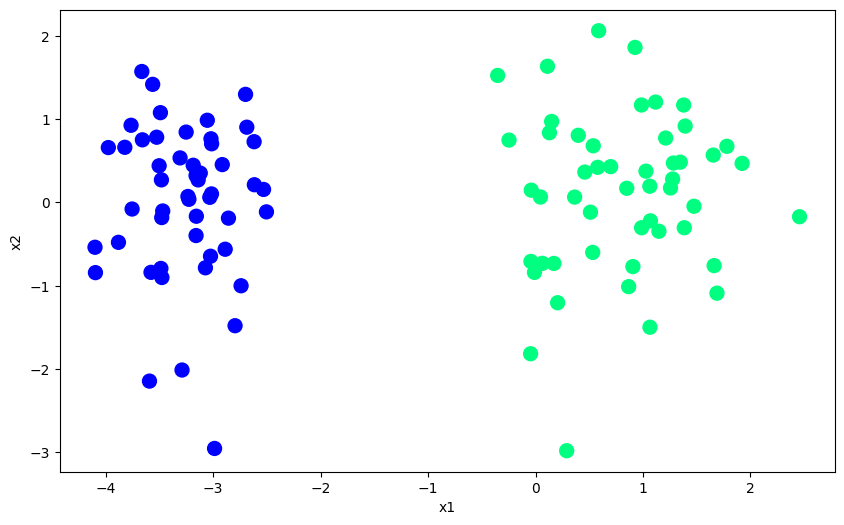

In [2]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

## Step 2 — The math we will implement

**Prediction:** $\hat p = \sigma(Xw)$ (bias included via a column of 1s)

**Log-loss:**
$$L(w) = -\frac{1}{n}\sum_{i=1}^{n}\big[y_i\log\hat p_i + (1-y_i)\log(1-\hat p_i)\big]$$

**Gradient and update:**
$$\frac{\partial L}{\partial w} = \frac{1}{n}X^\top(\hat p - y) \qquad\Rightarrow\qquad w \leftarrow w + \eta\,\frac{1}{n}X^\top(y - \hat p)$$

Compare with notebook 02: identical form, but using **all** points per update (batch) instead of one random point.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def log_loss(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)            # avoid log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def gd(X, y, lr=0.5, epochs=5000):
    X = np.insert(X, 0, 1, axis=1)          # bias column
    weights = np.ones(X.shape[1])
    losses = []

    for i in range(epochs):
        y_hat = sigmoid(np.dot(X, weights))
        weights = weights + lr * (np.dot((y - y_hat), X) / X.shape[0])
        losses.append(log_loss(y, y_hat))

    return weights[1:], weights[0], losses

In [4]:
coef_, intercept_, losses = gd(X, y)
print("coef_     :", coef_)
print("intercept_:", intercept_)
print("final log-loss:", losses[-1])

coef_     : [4.83926872 0.21182255]
intercept_: 5.83338864905325
final log-loss: 0.0006328240501055581


## Step 3 — The loss curve

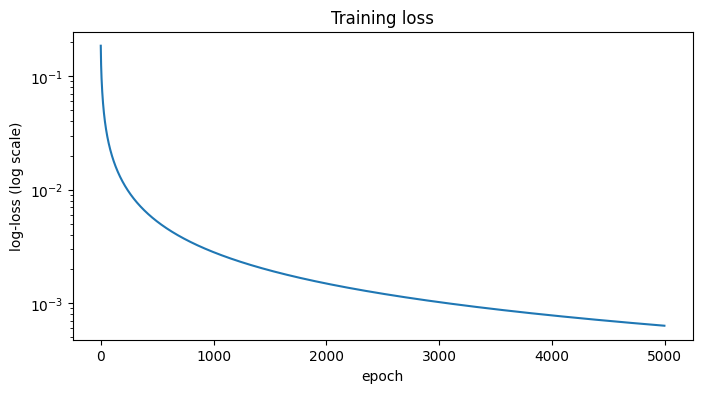

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('log-loss (log scale)')
plt.title('Training loss')
plt.show()

The loss falls quickly and keeps falling slowly, toward 0. Because the loss is **convex**, gradient descent heads steadily to the minimum without getting stuck.

## Step 4 — Compare with scikit-learn

In [6]:
def boundary_line(intercept, coef, x_range=np.linspace(-3, 3, 100)):
    """Points on w1*x1 + w2*x2 + b = 0, i.e. x2 = -(w1/w2)*x1 - b/w2  (theory §2)."""
    m = -(coef[0] / coef[1])
    c = -(intercept / coef[1])
    return x_range, m * x_range + c

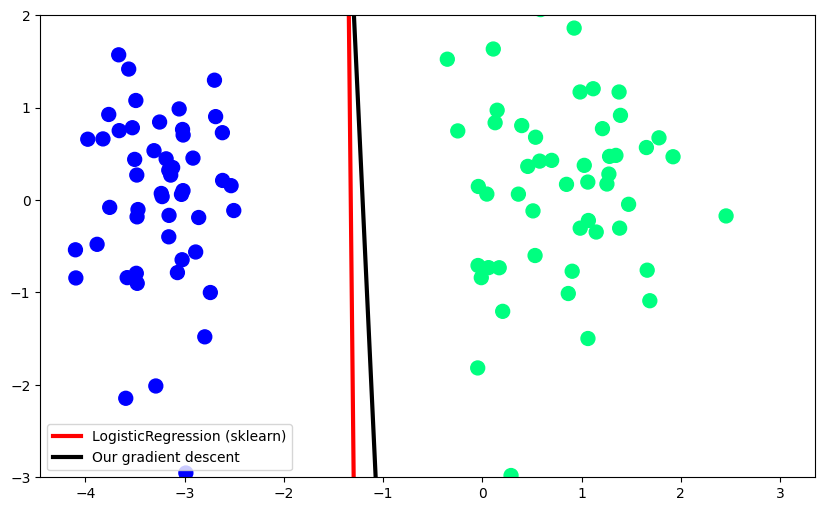

In [7]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression()
lor.fit(X, y)

x_l, y_l = boundary_line(lor.intercept_[0], lor.coef_[0])
x_g, y_g = boundary_line(intercept_, coef_)

plt.figure(figsize=(10, 6))
plt.plot(x_l, y_l, color='red', linewidth=3, label='LogisticRegression (sklearn)')
plt.plot(x_g, y_g, color='black', linewidth=3, label='Our gradient descent')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import accuracy_score

p_ours = sigmoid(intercept_ + X @ coef_)
print("Our accuracy    :", accuracy_score(y, (p_ours >= 0.5).astype(int)))
print("sklearn accuracy:", accuracy_score(y, lor.predict(X)))
print()
print("Our weights     :", np.r_[intercept_, coef_].round(3))
print("sklearn weights :", np.r_[lor.intercept_, lor.coef_[0]].round(3))

Our accuracy    : 1.0
sklearn accuracy: 1.0

Our weights     : [5.833 4.839 0.212]
sklearn weights : [3.136 2.367 0.023]


Both models classify every point correctly, and the boundaries are close. **But the weights are very different in size.** Why?

## Step 5 — Separable data makes weights grow forever (theory §8)

When a line separates the classes perfectly, making $w$ **bigger** pushes every $\hat p$ closer to exactly 0 or 1,
which always lowers the log-loss. Without a penalty there is no minimum, so the weights grow as long as you train:

In [9]:
for epochs in [100, 1000, 5000, 20000]:
    c, b, l = gd(X, y, epochs=epochs)
    print(f"epochs={epochs:>6}  |w| = {np.linalg.norm(np.r_[b, c]):6.2f}   log-loss = {l[-1]:.5f}")

epochs=   100  |w| =   3.40   log-loss = 0.01996
epochs=  1000  |w| =   5.69   log-loss = 0.00282
epochs=  5000  |w| =   7.58   log-loss = 0.00063


epochs= 20000  |w| =   9.31   log-loss = 0.00017


scikit-learn avoids this with **L2 regularisation** (default `C=1.0`), which penalises large weights and gives a
stable, finite solution. Smaller `C` means stronger regularisation:

In [10]:
for C in [0.01, 0.1, 1, 10, 100]:
    m = LogisticRegression(C=C).fit(X, y)
    print(f"C={C:<6}  |w| = {np.linalg.norm(np.r_[m.intercept_, m.coef_[0]]):6.2f}   "
          f"accuracy = {m.score(X, y):.2f}")

C=0.01    |w| =   0.81   accuracy = 1.00
C=0.1     |w| =   2.15   accuracy = 1.00
C=1       |w| =   3.93   accuracy = 1.00
C=10      |w| =   6.07   accuracy = 1.00
C=100     |w| =   8.13   accuracy = 1.00


> To turn regularisation off in modern scikit-learn, use `LogisticRegression(C=np.inf)`.
> The old `penalty='none'` no longer works.

### Key takeaways
- Logistic regression = sigmoid model + **log-loss**, minimised iteratively (no closed-form solution).
- Gradient: $\frac{1}{n}X^\top(\hat p - y)$, the same rule as the sigmoid perceptron, applied to all points.
- Log-loss is convex, so the loss curve decreases steadily.
- On separable data the unregularised weights diverge; regularisation (`C`) keeps them finite.

➡️ Next: **Day 39 — Classification metrics** (accuracy is not enough) and **Day 40 — Logistic regression continued** (polynomial features, softmax).